# JPX Cross-Sectional Stock Ranking — Consolidated Pipeline

This notebook consolidates `01_load_data`, `02_eda`, `03_preprocessing`, `04_features`,
and `05_model` into a single, reproducible, function-based pipeline.

**Nothing about the underlying logic, math, column names, ordering of operations, or
clipping/leakage-prevention design has been changed.** Every computation below is the
exact same computation as in the original notebooks — it has only been organized into
named functions with explicit inputs/outputs instead of loose top-level cells, and the
hard-coded Windows paths have been centralized into one `PROJECT_ROOT` variable so the
whole thing runs end-to-end with a single "Run All".

Pipeline stages:
1. **Load & inspect raw data** (`01_load_data`)
2. **EDA, document filtering, quarterization, TTM** (`02_eda`)
3. **Point-in-time merge & feature engineering** (`03_preprocessing`)
4. **Leak-free target clipping, imputation, size-quintile neutralisation** (`04_features`)
5. **Walk-forward XGBRanker training & evaluation** (`05_model`)

Each stage function also writes its output to disk at the *same* path the original
notebook used (including the `processedstock_prices_clean.csv` naming — kept exactly
as-is so downstream stages that expect that exact filename keep working unchanged),
so you can still re-run any single stage independently by loading from disk instead of
from memory.


In [1]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dateutil.relativedelta import relativedelta
from scipy.stats import spearmanr

warnings.filterwarnings("ignore")

# ------------------------------------------------------------------
# SINGLE SOURCE OF TRUTH FOR ALL PATHS
# Change PROJECT_ROOT if this notebook lives somewhere else; every
# path below is derived from it exactly the way the original five
# notebooks derived their (hard-coded) paths.
# ------------------------------------------------------------------
PROJECT_ROOT = Path(r"C:\Users\naksh\Projects\xgboost_stock_ranking")

RAW_DIR   = PROJECT_ROOT / "data" / "raw"
DATA_DIR  = PROJECT_ROOT / "data"
PROC_DIR  = PROJECT_ROOT / "data" / "processed"
MODEL_DIR = PROJECT_ROOT / "models"

# NOTE: the original 01_load_data notebook saved to a path missing a
# separator between "processed" and the filename, e.g.
#   data\\processedstock_prices_clean.csv
# i.e. a file literally named "processedstock_prices_clean.csv" sitting
# directly in data/, NOT inside data/processed/. 02_eda and 03_preprocessing
# both read it back from that exact same (mis-spelled) location, so the
# pipeline is internally consistent. We reproduce that exact filename here
# rather than "fixing" it, to guarantee byte-for-byte reproducibility with
# your existing folder structure / any files you already have on disk.
STOCK_PRICES_CLEAN_PATH = DATA_DIR / "processedstock_prices_clean.csv"
FINANCIALS_CLEAN_PATH   = DATA_DIR / "processedfinancials_clean.csv"
STATEMENTS_QUARTERIZED_PATH = DATA_DIR / "statements_quarterized.csv"
MONTHLY_FEATURES_PATH   = DATA_DIR / "monthly_features.csv"
FEATURE_COLS_PATH       = PROC_DIR / "feature_cols.json"
MODEL_DATA_PATH         = DATA_DIR / "model_data.csv"
BEST_PARAMS_PATH        = DATA_DIR / "best_xgbranker_params.json"

for d in (RAW_DIR, PROC_DIR, MODEL_DIR):
    d.mkdir(parents=True, exist_ok=True)


## Stage 1 — Load & Inspect Raw Data

*(from `01_load_data.ipynb`)*

Load the two raw CSVs, do a basic schema/quality inspection, then write cleaned versions to disk.

In [2]:
def load_raw_data(raw_dir: Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Load stock_prices.csv and financials.csv from raw_dir."""
    stock_prices = pd.read_csv(raw_dir / "stock_prices.csv")
    financials = pd.read_csv(raw_dir / "financials.csv")

    print("stock_prices:", stock_prices.shape)
    print("financials  :", financials.shape)
    return stock_prices, financials


In [3]:
def inspect_schema(stock_prices: pd.DataFrame, financials: pd.DataFrame) -> None:
    """Print column lists, dtypes/info, and missing rates for both raw frames."""
    print("=== stock_prices columns ===")
    print(stock_prices.columns.tolist())

    print("\n=== financials columns ===")
    print(financials.columns.tolist())

    stock_prices.info()
    financials.info()

    print("=== stock_prices — missing rate ===")
    print(stock_prices.isna().mean().sort_values(ascending=False))

    print("\n=== financials — missing rate ===")
    print(financials.isna().mean().sort_values(ascending=False))


In [4]:
def parse_dates_stage1(stock_prices: pd.DataFrame, financials: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Parse Date / DisclosedDate columns to datetime."""
    stock_prices["Date"] = pd.to_datetime(stock_prices["Date"])

    for col in ["Date", "DisclosedDate"]:
        if col in financials.columns:
            financials[col] = pd.to_datetime(financials[col])

    return stock_prices, financials


In [5]:
def duplicate_and_universe_checks(stock_prices: pd.DataFrame, financials: pd.DataFrame) -> None:
    """Report duplicate rows and ticker-universe overlap between the two frames."""
    print("stock_prices duplicates:", stock_prices.duplicated().sum())
    print("financials   duplicates:", financials.duplicated().sum())

    price_codes = set(stock_prices["SecuritiesCode"].unique())
    financial_codes = set(financials["SecuritiesCode"].unique())
    common_codes = price_codes & financial_codes

    print(f"\nTickers in prices       : {len(price_codes)}")
    print(f"Tickers in financials   : {len(financial_codes)}")
    print(f"Tickers in both         : {len(common_codes)}")
    print(f"Only in financials      : {len(financial_codes - price_codes)}")


In [6]:
def save_stage1_outputs(stock_prices: pd.DataFrame, financials: pd.DataFrame,
                         stock_prices_clean_path: Path, financials_clean_path: Path) -> None:
    """Persist cleaned stock_prices / financials to disk (paths kept identical to the original notebook)."""
    stock_prices.to_csv(stock_prices_clean_path, index=False)
    financials.to_csv(financials_clean_path, index=False)

    print("Saved:", stock_prices_clean_path.name)
    print("Saved:", financials_clean_path.name)


In [7]:
def run_stage1_load_and_inspect(raw_dir: Path, stock_prices_clean_path: Path,
                                 financials_clean_path: Path, verbose: bool = True):
    """Orchestrates Stage 1 exactly as 01_load_data.ipynb executed top-to-bottom."""
    stock_prices, financials = load_raw_data(raw_dir)
    if verbose:
        inspect_schema(stock_prices, financials)
    stock_prices, financials = parse_dates_stage1(stock_prices, financials)
    if verbose:
        duplicate_and_universe_checks(stock_prices, financials)
    save_stage1_outputs(stock_prices, financials, stock_prices_clean_path, financials_clean_path)
    return stock_prices, financials


## Stage 2 — EDA, Document Filtering & Quarterization

*(from `02_eda.ipynb`)*

Understand document types, keep only JP-consolidated statements + forecast revisions, quarterize cumulative income-statement figures, and build TTM sums.

In [8]:
def analyze_document_types(financials: pd.DataFrame) -> None:
    """Print TypeOfDocument value counts and accounting-standard breakdown."""
    print(financials["TypeOfDocument"].value_counts())
    print("\nAccounting standard breakdown:")
    print(financials["TypeOfDocument"].str.extract(r"(JP|IFRS|US)")[0].value_counts())


In [9]:
KEEP_DOCS = [
    "ForecastRevision",
    "1QFinancialStatements_Consolidated_JP",
    "2QFinancialStatements_Consolidated_JP",
    "3QFinancialStatements_Consolidated_JP",
    "FYFinancialStatements_Consolidated_JP",
]

STATEMENT_DOCS = [
    "1QFinancialStatements_Consolidated_JP",
    "2QFinancialStatements_Consolidated_JP",
    "3QFinancialStatements_Consolidated_JP",
    "FYFinancialStatements_Consolidated_JP",
]

QUARTER_MAP = {
    "1QFinancialStatements_Consolidated_JP": 1,
    "2QFinancialStatements_Consolidated_JP": 2,
    "3QFinancialStatements_Consolidated_JP": 3,
    "FYFinancialStatements_Consolidated_JP": 4,
}

NUMERIC_COLS = [
    # Income statement
    "NetSales", "OperatingProfit", "OrdinaryProfit", "Profit",
    # Balance sheet
    "TotalAssets", "Equity",
    # Per-share
    "BookValuePerShare", "EarningsPerShare",
    # Forecasts
    "ForecastNetSales", "ForecastOperatingProfit", "ForecastOrdinaryProfit",
    "ForecastProfit", "ForecastEarningsPerShare",
    # Share counts
    "AverageNumberOfShares",
    "NumberOfIssuedAndOutstandingSharesAtTheEndOfFiscalYearIncludingTreasuryStock",
    "NumberOfTreasuryStockAtTheEndOfFiscalYear",
    # Ratios provided
    "EquityToAssetRatio",
]

DIVIDEND_COLS = [
    "ResultDividendPerShare1stQuarter",  "ResultDividendPerShare2ndQuarter",
    "ResultDividendPerShare3rdQuarter",  "ResultDividendPerShareFiscalYearEnd",
    "ResultDividendPerShareAnnual",
    "ForecastDividendPerShare1stQuarter", "ForecastDividendPerShare2ndQuarter",
    "ForecastDividendPerShare3rdQuarter", "ForecastDividendPerShareFiscalYearEnd",
    "ForecastDividendPerShareAnnual",
]

FLOW_COLS = ["NetSales", "OperatingProfit", "OrdinaryProfit", "Profit"]

TTM_BASE_COLS = [
    "q_NetSales",
    "q_OperatingProfit",
    "q_OrdinaryProfit",
    "q_Profit",
]


In [10]:
def filter_statements(financials: pd.DataFrame, stock_prices: pd.DataFrame) -> pd.DataFrame:
    """Keep only JP-Consolidated quarterly/annual statements + forecast revisions,
    restricted to tickers present in the price universe."""
    price_codes = set(stock_prices["SecuritiesCode"].unique())

    financials = (
        financials[
            financials["TypeOfDocument"].isin(KEEP_DOCS) &
            financials["SecuritiesCode"].isin(price_codes)
        ]
        .sort_values(["SecuritiesCode", "Date"])
        .copy()
    )

    print("After filtering:", financials.shape)
    return financials


In [11]:
def cast_numeric_columns(financials: pd.DataFrame) -> pd.DataFrame:
    """Coerce core numeric + dividend columns to numeric dtype."""
    financials[NUMERIC_COLS]  = financials[NUMERIC_COLS].apply(pd.to_numeric,  errors="coerce")
    financials[DIVIDEND_COLS] = financials[DIVIDEND_COLS].apply(pd.to_numeric, errors="coerce")

    print("Missing rates for core numeric columns:")
    print(financials[NUMERIC_COLS].isna().mean().sort_values(ascending=False))
    return financials


In [12]:
def split_statements_forecasts(financials: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Split into true financial statements vs. forecast-revision rows."""
    statements = financials[financials["TypeOfDocument"].isin(STATEMENT_DOCS)].copy()
    forecasts  = financials[financials["TypeOfDocument"] == "ForecastRevision"].copy()

    print("statements:", statements.shape)
    print("forecasts :", forecasts.shape)
    return statements, forecasts


In [13]:
def quarterize_flows(statements: pd.DataFrame) -> pd.DataFrame:
    """JPX reports are cumulative (Q2 = H1 total); convert income-statement flows
    to true quarterly increments."""
    statements["quarter"]     = statements["TypeOfDocument"].map(QUARTER_MAP)
    statements["fiscal_year"] = pd.to_datetime(statements["CurrentPeriodEndDate"]).dt.year

    statements = statements.sort_values(["SecuritiesCode", "fiscal_year", "quarter"])

    prev_quarter = (
        statements
        .groupby(["SecuritiesCode", "fiscal_year"])["quarter"]
        .shift(1)
    )

    for col in FLOW_COLS:
        statements[f"q_{col}"] = np.nan

        q1_mask    = statements["quarter"] == 1
        valid_mask = (statements["quarter"] > 1) & (prev_quarter == statements["quarter"] - 1)

        statements.loc[q1_mask,    f"q_{col}"] = statements.loc[q1_mask, col]
        statements.loc[valid_mask, f"q_{col}"] = (
            statements.loc[valid_mask, col]
            - statements.groupby(["SecuritiesCode", "fiscal_year"])[col].shift(1).loc[valid_mask]
        )

    print("Quarterized columns missing rates:")
    print(statements[[f"q_{c}" for c in FLOW_COLS]].isna().mean())
    return statements


In [14]:
def compute_ttm(statements: pd.DataFrame) -> pd.DataFrame:
    """Trailing-twelve-month sums of the quarterized flow columns."""
    statements = statements.sort_values(["SecuritiesCode", "DisclosedDate"])

    for col in TTM_BASE_COLS:
        statements[f"{col}_ttm"] = (
            statements
            .groupby("SecuritiesCode")[col]
            .transform(lambda x: x.rolling(4, min_periods=4).sum())
        )

    return statements


In [15]:
def attach_shares_and_eps(statements: pd.DataFrame, financials: pd.DataFrame) -> pd.DataFrame:
    """Re-attach share-count and EPS columns from the (unfiltered-by-doc-type) financials frame."""
    statements[[
        "NumberOfIssuedAndOutstandingSharesAtTheEndOfFiscalYearIncludingTreasuryStock",
        "EarningsPerShare",
    ]] = financials[[
        "NumberOfIssuedAndOutstandingSharesAtTheEndOfFiscalYearIncludingTreasuryStock",
        "EarningsPerShare",
    ]]
    return statements


In [16]:
def save_stage2_outputs(statements: pd.DataFrame, statements_quarterized_path: Path) -> None:
    statements.to_csv(statements_quarterized_path, index=False)
    print(f"Saved: {statements_quarterized_path.name} — {statements.shape}")


In [17]:
def run_stage2_eda_and_quarterize(stock_prices: pd.DataFrame, financials: pd.DataFrame,
                                   statements_quarterized_path: Path, verbose: bool = True):
    """Orchestrates Stage 2 exactly as 02_eda.ipynb executed top-to-bottom."""
    if verbose:
        analyze_document_types(financials)

    financials = filter_statements(financials, stock_prices)
    financials = cast_numeric_columns(financials)
    statements, forecasts = split_statements_forecasts(financials)
    statements = quarterize_flows(statements)
    statements = compute_ttm(statements)
    statements = attach_shares_and_eps(statements, financials)

    save_stage2_outputs(statements, statements_quarterized_path)
    return statements


## Stage 3 — Point-in-Time Merge & Feature Engineering

*(from `03_preprocessing.ipynb`)*

- Statement `Date` is shifted forward by **+1 calendar day** before the `merge_asof` so a filing disclosed on day T can only appear in price snapshots from day T+1 onward (removes same-day look-ahead).
- Target clipping is intentionally **not** done here — see Stage 4, which clips using only training-fold statistics.

In [18]:
def add_profitability_ratios(statements: pd.DataFrame) -> pd.DataFrame:
    statements["roe"] = statements["q_Profit"] / statements["Equity"]
    statements["roa"] = statements["q_Profit"] / statements["TotalAssets"]
    statements["profit_margin"] = statements["q_Profit"] / statements["q_NetSales"]
    statements["operating_margin"] = statements["q_OperatingProfit"] / statements["q_NetSales"]
    statements["asset_turnover"] = statements["q_NetSales"] / statements["TotalAssets"]
    statements["equity_ratio"] = statements["Equity"] / statements["TotalAssets"]

    statements = statements.replace([np.inf, -np.inf], np.nan)
    return statements


In [19]:
def add_additional_profitability_factors(statements: pd.DataFrame) -> pd.DataFrame:
    statements["operating_roa"] = statements["q_OperatingProfit"] / statements["TotalAssets"]
    statements["ordinary_roa"] = statements["q_OrdinaryProfit"] / statements["TotalAssets"]
    statements["operating_roe"] = statements["q_OperatingProfit"] / statements["Equity"]
    statements["ordinary_roe"] = statements["q_OrdinaryProfit"] / statements["Equity"]
    statements["ordinary_margin"] = statements["q_OrdinaryProfit"] / statements["q_NetSales"]
    statements["profit_to_assets"] = statements["q_Profit"] / statements["TotalAssets"]
    statements["sales_to_equity"] = statements["q_NetSales"] / statements["Equity"]

    statements = statements.replace([np.inf, -np.inf], np.nan)
    return statements


In [20]:
PROFITABILITY_COLS = [
    "roe",
    "roa",
    "profit_margin",
    "operating_margin",
    "asset_turnover",
    "equity_ratio",
    "operating_roa",
    "ordinary_roa",
    "operating_roe",
    "ordinary_roe",
    "ordinary_margin",
    "profit_to_assets",
    "sales_to_equity",
]

def clip_profitability_columns(statements: pd.DataFrame) -> pd.DataFrame:
    for col in PROFITABILITY_COLS:
        lower = statements[col].quantile(0.01)
        upper = statements[col].quantile(0.99)
        statements[col] = statements[col].clip(lower=lower, upper=upper)
    return statements


In [21]:
GROWTH_COLS = ["q_NetSales", "q_Profit", "TotalAssets", "Equity"]
GROWTH_FEATURES = ["q_NetSales_yoy", "q_Profit_yoy", "TotalAssets_yoy", "Equity_yoy"]

def add_growth_features(statements: pd.DataFrame) -> pd.DataFrame:
    for col in GROWTH_COLS:
        statements[f"{col}_yoy"] = (
            statements
            .groupby("SecuritiesCode")[col]
            .pct_change(4)
        )

    for col in GROWTH_FEATURES:
        lower = statements[col].quantile(0.01)
        upper = statements[col].quantile(0.99)
        statements[col] = statements[col].clip(lower, upper)

    return statements


In [22]:
FORECAST_COLS = [
    "forecast_sales_growth",
    "forecast_profit_growth",
    "forecast_eps_growth",
    "forecast_operating_margin",
    "forecast_profit_margin",
    "forecast_roa",
    "forecast_roe",
]

def add_forecast_features(statements: pd.DataFrame) -> pd.DataFrame:
    statements["forecast_operating_margin"] = statements["ForecastOperatingProfit"] / statements["ForecastNetSales"]
    statements["forecast_profit_margin"] = statements["ForecastProfit"] / statements["ForecastNetSales"]
    statements["forecast_roa"] = statements["ForecastProfit"] / statements["TotalAssets"]
    statements["forecast_roe"] = statements["ForecastProfit"] / statements["Equity"]
    statements = statements.replace([np.inf, -np.inf], np.nan)

    statements["forecast_sales_growth"] = statements["ForecastNetSales"] / statements["NetSales"] - 1
    statements["forecast_profit_growth"] = statements["ForecastProfit"] / statements["Profit"] - 1
    statements["forecast_eps_growth"] = statements["ForecastEarningsPerShare"] / statements["EarningsPerShare"] - 1
    statements = statements.replace([np.inf, -np.inf], np.nan)

    for col in FORECAST_COLS:
        lower = statements[col].quantile(0.01)
        upper = statements[col].quantile(0.99)
        statements[col] = statements[col].clip(lower, upper)

    return statements


In [23]:
ACCEL_COLS = [
    "roe",
    "roa",
    "profit_margin",
    "operating_margin",
    "ordinary_margin",
    "asset_turnover",
    "sales_to_equity",
    "ttm_roe",
    "ttm_roa",
    "ttm_profit_margin",
    "ttm_asset_turnover",
]

def add_acceleration_features(statements: pd.DataFrame) -> pd.DataFrame:
    """4-quarter change ("acceleration") features, computed AFTER TTM profitability
    ratios exist (see add_ttm_profitability below) — matches original notebook order."""
    for col in ACCEL_COLS:
        statements[f"{col}_change_4q"] = (
            statements
            .groupby("SecuritiesCode")[col]
            .diff(4)
        )

    for col in statements.columns:
        if col.endswith("change_4q"):
            lower = statements[col].quantile(0.01)
            upper = statements[col].quantile(0.99)
            statements[col] = statements[col].clip(lower, upper)

    return statements


In [24]:
def add_ttm_profitability(statements: pd.DataFrame) -> pd.DataFrame:
    statements["ttm_roa"] = statements["q_Profit_ttm"] / statements["TotalAssets"]
    statements["ttm_roe"] = statements["q_Profit_ttm"] / statements["Equity"]
    statements["ttm_operating_roa"] = statements["q_OperatingProfit_ttm"] / statements["TotalAssets"]
    statements["ttm_operating_roe"] = statements["q_OperatingProfit_ttm"] / statements["Equity"]

    statements["ttm_profit_margin"] = statements["q_Profit_ttm"] / statements["q_NetSales_ttm"]
    statements["ttm_operating_margin"] = statements["q_OperatingProfit_ttm"] / statements["q_NetSales_ttm"]
    statements["ttm_ordinary_margin"] = statements["q_OrdinaryProfit_ttm"] / statements["q_NetSales_ttm"]

    statements["ttm_asset_turnover"] = statements["q_NetSales_ttm"] / statements["TotalAssets"]
    statements["ttm_sales_to_equity"] = statements["q_NetSales_ttm"] / statements["Equity"]
    statements["ttm_profit_to_assets"] = statements["q_Profit_ttm"] / statements["TotalAssets"]

    return statements


In [25]:
def clip_ttm_columns(statements: pd.DataFrame) -> pd.DataFrame:
    ttm_cols = [c for c in statements.columns if c.startswith("ttm_")]
    for c in ttm_cols:
        lo = statements[c].quantile(0.01)
        hi = statements[c].quantile(0.99)
        statements[c] = statements[c].clip(lo, hi)
    return statements


In [26]:
FINANCIAL_FEATURES_BASE = [
    "Date",
    "SecuritiesCode",
    # Raw accounting values
    "NetSales",
    "Profit",
    "TotalAssets",
    "Equity",
    # Quarterized values
    "q_NetSales",
    "q_OperatingProfit",
    "q_Profit",
    # Profitability
    "roe",
    "roa",
    "profit_margin",
    "operating_margin",
    "asset_turnover",
    "equity_ratio",
    # New profitability
    "operating_roa",
    "ordinary_roa",
    "operating_roe",
    "ordinary_roe",
    "ordinary_margin",
    "profit_to_assets",
    "sales_to_equity",
    # Growth
    "q_NetSales_yoy",
    "q_Profit_yoy",
    "TotalAssets_yoy",
    "Equity_yoy",
    # Forecast
    "forecast_sales_growth",
    "forecast_profit_growth",
    "forecast_eps_growth",
    # Forecast quality
    "forecast_operating_margin",
    "forecast_profit_margin",
    "forecast_roa",
    "forecast_roe",
    # ---------- TTM ----------
    "q_NetSales_ttm",
    "q_OperatingProfit_ttm",
    "q_OrdinaryProfit_ttm",
    "q_Profit_ttm",
    "ttm_roa",
    "ttm_roe",
    "ttm_operating_roa",
    "ttm_operating_roe",
    "ttm_profit_margin",
    "ttm_operating_margin",
    "ttm_ordinary_margin",
    "ttm_asset_turnover",
    "ttm_sales_to_equity",
    "ttm_profit_to_assets",
]

ACCELERATION_FEATURES = [
    "roe_change_4q",
    "roa_change_4q",
    "profit_margin_change_4q",
    "operating_margin_change_4q",
    "ordinary_margin_change_4q",
    "asset_turnover_change_4q",
    "sales_to_equity_change_4q",
    "ttm_roe_change_4q",
    "ttm_roa_change_4q",
    "ttm_profit_margin_change_4q",
    "ttm_asset_turnover_change_4q",
]

def build_statements_small(statements: pd.DataFrame, prices: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Select the merge-ready subset of statement columns and align dtypes with prices."""
    financial_features = FINANCIAL_FEATURES_BASE + ACCELERATION_FEATURES

    statements_small = statements[financial_features].copy()
    statements_small[[
        "NumberOfIssuedAndOutstandingSharesAtTheEndOfFiscalYearIncludingTreasuryStock",
        "EarningsPerShare",
    ]] = statements[[
        "NumberOfIssuedAndOutstandingSharesAtTheEndOfFiscalYearIncludingTreasuryStock",
        "EarningsPerShare",
    ]]

    prices = prices.copy()
    prices["SecuritiesCode"] = prices["SecuritiesCode"].astype("int64")
    statements_small["SecuritiesCode"] = statements_small["SecuritiesCode"].astype("int64")

    return prices, statements_small


In [27]:
def apply_disclosure_embargo(prices: pd.DataFrame, statements_small: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Shift statement Date forward by +1 calendar day (Date == DisclosedDate in the raw
    data, verified 100% match), so the earliest a filing can enter any price row is T+1 —
    the first point at which an investor could actually have traded on that information."""
    statements_small = statements_small.copy()
    statements_small["Date"] = statements_small["Date"] + pd.Timedelta(days=1)

    prices = prices.sort_values(["Date", "SecuritiesCode"]).reset_index(drop=True)
    statements_small = statements_small.sort_values(["Date", "SecuritiesCode"]).reset_index(drop=True)

    return prices, statements_small


In [28]:
def merge_asof_pit(prices: pd.DataFrame, statements_small: pd.DataFrame) -> pd.DataFrame:
    """Point-in-time backward merge_asof of statement data onto the daily price panel."""
    merged = pd.merge_asof(
        prices,
        statements_small,
        on="Date",
        by="SecuritiesCode",
        direction="backward",
    )

    print("prices :", prices.shape)
    print("merged :", merged.shape)
    return merged


In [29]:
def resample_to_monthly(merged: pd.DataFrame) -> pd.DataFrame:
    """Take the last daily row within each (SecuritiesCode, YearMonth) as the monthly snapshot."""
    merged = merged.copy()
    merged["YearMonth"] = merged["Date"].dt.to_period("M")

    monthly = (
        merged
        .sort_values(["SecuritiesCode", "Date"])
        .groupby(["SecuritiesCode", "YearMonth"], as_index=False)
        .last()
    )

    print("monthly:", monthly.shape)
    print("Duplicates (SecuritiesCode, YearMonth):", monthly.duplicated(["SecuritiesCode", "YearMonth"]).sum())
    return monthly


In [30]:
def compute_target(monthly: pd.DataFrame) -> pd.DataFrame:
    """1-month forward return target. NOT clipped here — see Stage 4."""
    monthly["target_1m"] = (
        monthly.groupby("SecuritiesCode")["Close"]
        .shift(-1)
        / monthly["Close"]
        - 1
    )

    print(monthly["target_1m"].describe())
    return monthly


In [31]:
def add_momentum_features(monthly: pd.DataFrame) -> pd.DataFrame:
    for m in [1, 3, 6, 12]:
        monthly[f"mom_{m}m"] = (
            monthly.groupby("SecuritiesCode")["Close"]
            .pct_change(m)
        )

    for m in [3, 6, 12]:
        ma = (
            monthly.groupby("SecuritiesCode")["Close"]
            .transform(lambda x: x.rolling(m).mean())
        )
        monthly[f"ma_{m}m_ratio"] = monthly["Close"] / ma

    return monthly


In [32]:
def add_risk_liquidity_features(merged: pd.DataFrame) -> tuple[pd.DataFrame, list[str]]:
    """Daily-frequency risk/liquidity features, later merged back onto the monthly panel."""
    merged = merged.sort_values(["SecuritiesCode", "Date"]).copy()
    merged["daily_return"] = (
        merged.groupby("SecuritiesCode")["Close"].pct_change()
    )

    # Cross-sectional market return
    merged["market_return"] = (
        merged.groupby("Date")["daily_return"]
              .transform("mean")
    )

    # Residual return (beta≈1 approximation)
    merged["idio_return"] = (
        merged["daily_return"] - merged["market_return"]
    )

    # Idiosyncratic volatility
    for days, name in zip([21, 63, 126], [1, 3, 6]):
        merged[f"idio_vol_{name}m"] = (
            merged
            .groupby("SecuritiesCode")["idio_return"]
            .transform(lambda x: x.rolling(days).std())
        )

    # Idiosyncratic skewness
    for days, name in zip([63, 126], [3, 6]):
        merged[f"idio_skew_{name}m"] = (
            merged
            .groupby("SecuritiesCode")["idio_return"]
            .transform(lambda x: x.rolling(days).skew())
        )

    for days, name in zip([21, 63, 126, 252], [1, 3, 6, 12]):
        merged[f"vol_{name}m"] = (
            merged.groupby("SecuritiesCode")["daily_return"]
            .transform(lambda x: x.rolling(days).std())
        )

    for days, name in zip([63, 126, 252], [3, 6, 12]):
        merged[f"skew_{name}m"] = (
            merged.groupby("SecuritiesCode")["daily_return"]
            .transform(lambda x: x.rolling(days).skew())
        )

    for days, name in zip([63, 126, 252], [3, 6, 12]):
        merged[f"max_return_{name}m"] = (
            merged.groupby("SecuritiesCode")["daily_return"]
            .transform(lambda x: x.rolling(days).max())
        )

    merged["dollar_volume"] = merged["Close"] * merged["Volume"]

    for days, name in zip([21, 63], [1, 3]):
        merged[f"avg_dollar_vol_{name}m"] = (
            merged.groupby("SecuritiesCode")["dollar_volume"]
            .transform(lambda x: x.rolling(days).mean())
        )

    merged["rel_volume"] = (
        merged["Volume"]
        / merged.groupby("SecuritiesCode")["Volume"]
                 .transform(lambda x: x.rolling(63).mean())
    )

    daily_feature_cols = [
        "vol_1m", "vol_3m", "vol_6m", "vol_12m",
        "skew_3m", "skew_6m", "skew_12m",
        "max_return_3m",
        "avg_dollar_vol_1m",
        "rel_volume",
    ]

    return merged, daily_feature_cols


In [33]:
def merge_daily_features_into_monthly(monthly: pd.DataFrame, merged: pd.DataFrame,
                                       daily_feature_cols: list[str]) -> pd.DataFrame:
    monthly = monthly.merge(
        merged[["SecuritiesCode", "Date"] + daily_feature_cols],
        on=["SecuritiesCode", "Date"],
        how="left",
    )
    return monthly


In [34]:
def add_valuation_features(monthly: pd.DataFrame) -> pd.DataFrame:
    EPS = 1e-8

    def safe_div(num, den):
        den = den.where(den.abs() > EPS)
        return num / den

    shares = monthly["NumberOfIssuedAndOutstandingSharesAtTheEndOfFiscalYearIncludingTreasuryStock"]

    monthly["market_cap"] = monthly["Close"] * shares
    monthly["log_market_cap"] = np.log1p(monthly["market_cap"])

    monthly["price_to_earnings"] = safe_div(monthly["Close"], monthly["EarningsPerShare"])
    monthly["earnings_yield"] = safe_div(monthly["EarningsPerShare"], monthly["Close"])

    monthly = monthly.replace([np.inf, -np.inf], np.nan)
    return monthly


In [35]:
def finalize_feature_list_and_clip(monthly: pd.DataFrame) -> tuple[pd.DataFrame, list[str]]:
    """Drop helper/leak columns, drop known highly-correlated columns, build the final
    feature_cols list, and apply a global 1%/99% clip to every numeric feature."""
    drop_cols = ["YearMonth", "ExpectedDividend", "Target"]
    monthly = monthly.drop(columns=[c for c in drop_cols if c in monthly.columns])

    # Drop highly correlated columns identified from the original notebook
    monthly = monthly.drop(
        columns=[
            c for c in ["max_return_6m", "max_return_12m", "avg_dollar_vol_3m", "q_OrdinaryProfit"]
            if c in monthly.columns
        ]
    )

    exclude_cols = {
        "Date", "SecuritiesCode", "RowId", "target_1m",
        "Open", "High", "Low", "Close", "Volume",
        "ExpectedDividend", "Target", "market_cap"
    }

    feature_cols = [
        c for c in monthly.columns
        if c not in exclude_cols
        and monthly[c].dtype in ["float64", "float32", "int64", "int32"]
    ]

    monthly = monthly.replace([np.inf, -np.inf], np.nan)

    for col in feature_cols:
        lower = monthly[col].quantile(0.01)
        upper = monthly[col].quantile(0.99)
        monthly[col] = monthly[col].clip(lower, upper)

    print(f"Feature count: {len(feature_cols)}")
    print(monthly[feature_cols].isna().mean().sort_values(ascending=False).head(55))

    return monthly, feature_cols


In [36]:
def save_stage3_outputs(monthly: pd.DataFrame, feature_cols: list[str],
                         monthly_features_path: Path, feature_cols_path: Path) -> None:
    monthly.to_csv(monthly_features_path, index=False)

    with open(feature_cols_path, "w") as f:
        json.dump(feature_cols, f, indent=4)

    print(f"Saved: {monthly_features_path.name} — {monthly.shape}")
    print(f"Saved: {feature_cols_path.name}   — {len(feature_cols)} features")


In [37]:
def run_stage3_preprocess_and_engineer(prices: pd.DataFrame, statements: pd.DataFrame,
                                        monthly_features_path: Path, feature_cols_path: Path):
    """Orchestrates Stage 3 exactly as 03_preprocessing.ipynb executed top-to-bottom."""
    prices = prices.sort_values(["SecuritiesCode", "Date"]).copy()
    statements = statements.copy()

    # Order below matches the original notebook cell-for-cell:
    # profitability -> additional profitability -> TTM profitability -> clip TTM ->
    # clip (non-TTM) profitability -> growth -> forecast -> acceleration.
    statements = add_profitability_ratios(statements)
    statements = add_additional_profitability_factors(statements)

    statements = add_ttm_profitability(statements)
    statements = clip_ttm_columns(statements)
    statements = clip_profitability_columns(statements)

    statements = add_growth_features(statements)
    statements = add_forecast_features(statements)
    statements = add_acceleration_features(statements)

    prices, statements_small = build_statements_small(statements, prices)
    prices, statements_small = apply_disclosure_embargo(prices, statements_small)

    merged = merge_asof_pit(prices, statements_small)
    monthly = resample_to_monthly(merged)
    monthly = compute_target(monthly)
    monthly = add_momentum_features(monthly)

    merged, daily_feature_cols = add_risk_liquidity_features(merged)
    monthly = merge_daily_features_into_monthly(monthly, merged, daily_feature_cols)
    monthly = add_valuation_features(monthly)

    monthly, feature_cols = finalize_feature_list_and_clip(monthly)

    save_stage3_outputs(monthly, feature_cols, monthly_features_path, feature_cols_path)
    return monthly, feature_cols


## Stage 4 — Leak-Free Target Clipping, Imputation & Size-Quintile Neutralisation

*(from `04_features.ipynb`)*

1. **Leak-free target clipping** — `target_1m` clipped using quantiles computed on the **training window only** (`Date < TRAIN_END`), then applied to all rows.
2. **Cross-sectional median imputation** — same as original, fill NaNs with the cross-sectional median for each date.
3. **Size-quintile neutralisation** — no sector codes exist in this dataset, so `avg_dollar_vol_1m` is used as a size proxy. Fundamental features are z-scored *within* quintile × date cells; price/technical features are z-scored across the full cross-section.

In [38]:
TRAIN_END = "2020-01-01"  # must match the earliest test-fold start used in Stage 5
SIZE_PROXY = "avg_dollar_vol_1m"
N_QUINTILES = 5

PRICE_EXACT = {
    "log_market_cap",
    "price_to_earnings",
    "earnings_yield",
    "dividend_yield",
    "forecast_dividend_yield",
    "treasury_share_ratio",
}

PRICE_PREFIXES = [
    "mom_",
    "ma_",
    "vol_",
    "skew_",
    "max_return_",
    "avg_dollar_vol_",
    "rel_volume",
    "AdjustmentFactor", "SupervisionFlag",
]


In [39]:
def leak_free_target_clip(monthly: pd.DataFrame, target_col: str, train_end: str) -> pd.DataFrame:
    """Clip target_1m using quantiles computed on rows before train_end only."""
    monthly = monthly.dropna(subset=[target_col]).copy()
    print("Shape after dropping missing target:", monthly.shape)

    train_mask   = monthly["Date"] < train_end
    target_lower = monthly.loc[train_mask, target_col].quantile(0.01)
    target_upper = monthly.loc[train_mask, target_col].quantile(0.99)

    monthly[target_col] = monthly[target_col].clip(target_lower, target_upper)

    print(f"Target clip bounds (from train): [{target_lower:.4f}, {target_upper:.4f}]")
    print(monthly[target_col].describe())
    return monthly


In [40]:
def cross_sectional_median_impute(monthly: pd.DataFrame, feature_cols: list[str]) -> pd.DataFrame:
    """Fill NaNs with the cross-sectional (same-date) median for each date, then 0 as a final fallback."""
    monthly = monthly.copy()
    monthly[feature_cols] = (
        monthly
        .groupby("Date")[feature_cols]
        .transform(lambda x: x.fillna(x.median()))
    )
    monthly[feature_cols] = monthly[feature_cols].fillna(0)

    print("Remaining NaNs after imputation:", monthly[feature_cols].isna().sum().sum())
    return monthly


In [41]:
def size_quintile_neutralize(monthly: pd.DataFrame, feature_cols: list[str],
                              size_proxy: str = SIZE_PROXY, n_quintiles: int = N_QUINTILES) -> pd.DataFrame:
    """Z-score fundamental features within [Date x size_quintile]; z-score price/technical
    features within [Date] across the full cross-section."""
    monthly = monthly.copy()

    monthly["size_quintile"] = (
        monthly
        .groupby("Date")[size_proxy]
        .transform(lambda x: pd.qcut(x.rank(method="first"), q=n_quintiles, labels=False))
    )

    price_features = [
        f for f in feature_cols
        if (f in PRICE_EXACT or any(f.startswith(prefix) for prefix in PRICE_PREFIXES))
    ]
    fundamental_features = [f for f in feature_cols if f not in price_features]

    print(f"Price/technical features  ({len(price_features)}): z-scored cross-sectionally")
    print(f"Fundamental features      ({len(fundamental_features)}): z-scored within size quintile")

    monthly[fundamental_features] = (
        monthly
        .groupby(["Date", "size_quintile"])[fundamental_features]
        .transform(lambda x: (x - x.mean()) / (x.std() + 1e-8))
    )

    monthly[price_features] = (
        monthly
        .groupby("Date")[price_features]
        .transform(lambda x: (x - x.mean()) / (x.std() + 1e-8))
    )

    print("Final shape:", monthly.shape)

    monthly = monthly.drop(columns=["size_quintile"])
    return monthly


In [42]:
def save_stage4_outputs(monthly: pd.DataFrame, model_data_path: Path) -> None:
    monthly.to_csv(model_data_path, index=False)
    print(f"Saved: {model_data_path.name} —", monthly.shape)


In [43]:
def run_stage4_prepare_model_data(monthly: pd.DataFrame, feature_cols: list[str],
                                   model_data_path: Path, train_end: str = TRAIN_END,
                                   target_col: str = "target_1m"):
    """Orchestrates Stage 4 exactly as 04_features.ipynb executed top-to-bottom."""
    monthly = leak_free_target_clip(monthly, target_col, train_end)
    monthly = cross_sectional_median_impute(monthly, feature_cols)
    monthly = size_quintile_neutralize(monthly, feature_cols)

    save_stage4_outputs(monthly, model_data_path)
    return monthly


## Stage 5 — Walk-Forward XGBRanker Training & Evaluation

*(from `05_model.ipynb`)*

Expanding-window walk-forward CV: each fold trains on all data up to the fold start, then tests on the next 6 months (1-month gap between train-end and test-start to avoid leakage at the lagged-monthly-return boundary). The model is retrained from scratch every fold; IC and long-short returns are accumulated across all test folds.

In [44]:
def add_rank_target(monthly: pd.DataFrame, n_buckets: int = 32) -> pd.DataFrame:
    """Ordinal rank target (n_buckets buckets per month) used by XGBRanker."""
    monthly = monthly.copy()
    monthly["rank_target"] = (
        monthly.groupby("Date")["target_1m"]
        .transform(lambda x: pd.qcut(x.rank(method="first"), q=n_buckets, labels=False))
        .astype(int)
    )
    return monthly


In [45]:
def build_walk_forward_folds(monthly: pd.DataFrame, min_train_months: int = 36,
                              test_fold_months: int = 6, gap_months: int = 1) -> list[dict]:
    """Expanding-window walk-forward fold definitions with a gap between train end and test start."""
    all_months = sorted(monthly["Date"].dt.to_period("M").unique())

    folds = []
    fold_start_idx = min_train_months  # first test fold starts after min_train_months

    while fold_start_idx + gap_months < len(all_months):
        train_end_period = all_months[fold_start_idx - 1]           # last training month
        test_start_period = all_months[fold_start_idx + gap_months]  # after gap
        test_end_idx = min(fold_start_idx + gap_months + test_fold_months - 1, len(all_months) - 1)
        test_end_period = all_months[test_end_idx]

        folds.append({
            "train_end":  train_end_period.to_timestamp(how="end"),
            "test_start": test_start_period.to_timestamp(how="start"),
            "test_end":   test_end_period.to_timestamp(how="end"),
        })

        fold_start_idx += test_fold_months  # advance by one test fold

    print(f"{len(folds)} folds:")
    for i, f in enumerate(folds):
        print(f"  Fold {i}: train ≤ {f['train_end'].date()}  |  "
              f"test {f['test_start'].date()} → {f['test_end'].date()}")

    return folds


In [46]:
def load_best_params(best_params_path: Path) -> dict:
    """Load tuned XGBRanker hyperparameters.

    NOTE: this deliberately has NO fallback. The original 05_model.ipynb had none
    either — it assumed best_xgbranker_params.json (produced by your hyperparameter-
    tuning notebook) already exists at this path and would raise if it didn't. An
    earlier version of this consolidated notebook added a silent default-parameter
    fallback here "for convenience" — that was a mistake: if the file isn't found
    at exactly this path, it would train with generic (untuned) hyperparameters
    instead of yours, giving a quietly worse — but not obviously broken — result.
    If this raises FileNotFoundError, point BEST_PARAMS_PATH at wherever your
    tuning notebook actually wrote the file, rather than adding a fallback back in.
    """
    with open(best_params_path, "r") as f:
        best_params = json.load(f)
    print(f"Loaded tuned params from {best_params_path.name}: {best_params}")
    return best_params


In [47]:
def train_walk_forward(monthly: pd.DataFrame, feature_cols: list[str], folds: list[dict],
                        best_params: dict, target_col: str = "rank_target"):
    """Train one XGBRanker per fold (expanding window, 6-month internal validation tail
    for early stopping), predict on the fold's test window, and accumulate OOS predictions."""
    from xgboost import XGBRanker

    all_test_predictions = []
    trained_models = []
    last_train_df = None

    for fold_idx, fold in enumerate(folds):

        train_df = monthly[monthly["Date"] <= fold["train_end"]].copy()
        test_df  = monthly[
            (monthly["Date"] >= fold["test_start"]) &
            (monthly["Date"] <= fold["test_end"])
        ].copy()

        if len(train_df) == 0 or len(test_df) == 0:
            continue

        # Use the last 6 months of training as internal validation for early stopping
        val_cutoff = train_df["Date"].max() - pd.DateOffset(months=6)
        inner_train = train_df[train_df["Date"] <= val_cutoff]
        inner_valid = train_df[train_df["Date"] >  val_cutoff]

        X_tr, y_tr = inner_train[feature_cols], inner_train[target_col]
        X_va, y_va = inner_valid[feature_cols], inner_valid[target_col]
        X_te       = test_df[feature_cols]

        group_tr = inner_train.groupby("Date").size().to_list()
        group_va = inner_valid.groupby("Date").size().to_list()

        ranker = XGBRanker(
            objective="rank:pairwise",
            eval_metric="ndcg",
            n_estimators=1000,
            tree_method="hist",
            early_stopping_rounds=50,
            random_state=42,
            **best_params
        )

        ranker.fit(
            X_tr, y_tr,
            group=group_tr,
            eval_set=[(X_tr, y_tr), (X_va, y_va)],
            eval_group=[group_tr, group_va],
            verbose=False,
        )
        trained_models.append(ranker)

        test_df = test_df.copy()
        test_df["score"] = ranker.predict(X_te)
        test_df["fold"] = fold_idx

        all_test_predictions.append(test_df)
        last_train_df = train_df

        # Per-fold IC summary
        fold_ic = (
            test_df.groupby("Date")
                   .apply(lambda x: spearmanr(x["score"], x["target_1m"]).correlation,
                          include_groups=False)
        )
        print(f"Fold {fold_idx}: best_iter={ranker.best_iteration}  "
              f"mean_IC={fold_ic.mean():.4f}  IC>0={(fold_ic > 0).mean():.0%}")

    oos = pd.concat(all_test_predictions, ignore_index=True)
    print(f"\nTotal OOS rows: {len(oos):,}")

    return oos, trained_models, last_train_df


In [48]:
def summarize_oos_ic(oos: pd.DataFrame) -> tuple[pd.Series, float, float]:
    monthly_ic = (
        oos.groupby("Date")
           .apply(lambda x: spearmanr(x["score"], x["target_1m"]).correlation,
                  include_groups=False)
    )

    icir = monthly_ic.mean() / (monthly_ic.std() + 1e-8)
    annual_icir = icir * np.sqrt(12)

    print("=== OOS IC Summary (all folds combined) ===")
    print(monthly_ic.describe())
    print(f"\nMean IC  : {monthly_ic.mean():.4f}")
    print(f"ICIR     : {icir:.4f}")
    print(f"Annual ICIR   : {annual_icir:.4f}")
    print(f"IC > 0   : {(monthly_ic > 0).mean():.2%}")

    return monthly_ic, icir, annual_icir


In [49]:
def save_models(trained_models: list, model_dir: Path) -> None:
    import joblib
    for i, model in enumerate(trained_models):
        joblib.dump(model, model_dir / f"model_fold_{i}.pkl")
    print(f"Saved {len(trained_models)} models.")


In [50]:
def long_short_return(df: pd.DataFrame) -> float:
    df = df.sort_values("score")
    n = max(1, int(len(df) * 0.10))
    return df.iloc[-n:]["target_1m"].mean() - df.iloc[:n]["target_1m"].mean()

def long_short_backtest(oos: pd.DataFrame) -> pd.Series:
    portfolio = oos.groupby("Date").apply(long_short_return, include_groups=False)

    print(portfolio.describe())
    print(f"\nAverage monthly L/S return : {portfolio.mean():.4%}")
    print(f"Annualised Sharpe (approx) : {portfolio.mean() / portfolio.std() * np.sqrt(12):.2f}")

    return portfolio


In [51]:
def plot_equity_and_ic(portfolio: pd.Series, monthly_ic: pd.Series) -> None:
    equity = (1 + portfolio).cumprod()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    equity.plot(ax=axes[0], title="Long-Short Equity Curve (XGBRanker, Walk-Forward)")
    axes[0].set_ylabel("Cumulative Return")
    axes[0].grid(True)

    monthly_ic.plot(ax=axes[1], alpha=0.5, label="Monthly IC")
    monthly_ic.rolling(3).mean().plot(ax=axes[1], label="3m rolling mean", linewidth=2)
    axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
    axes[1].set_title("OOS Information Coefficient")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()


In [52]:
def plot_ic_by_size(oos: pd.DataFrame) -> pd.Series:
    tmp = oos.copy()

    tmp["size_quintile"] = (
        tmp.groupby("Date")["avg_dollar_vol_1m"]
           .transform(lambda x: pd.qcut(x.rank(method="first"), 5, labels=False, duplicates="drop"))
    )

    ic_size = (
        tmp.groupby(["Date", "size_quintile"])
           .apply(lambda x: spearmanr(x["score"], x["target_1m"]).correlation, include_groups=False)
           .groupby(level=1)
           .mean()
    )

    ic_size.plot.bar(figsize=(7, 4))
    plt.ylabel("Mean IC")
    plt.title("IC by Size Quintile")
    plt.show()

    print(ic_size)
    return ic_size


In [53]:
def compute_turnover(oos: pd.DataFrame, top_pct: float = 0.10) -> pd.DataFrame:
    dates = sorted(oos["Date"].unique())

    top_sets = {}
    bottom_sets = {}

    for date in dates:
        df = oos[oos["Date"] == date].sort_values("score")
        n = max(1, int(len(df) * top_pct))

        bottom_sets[date] = set(df.head(n)["SecuritiesCode"])
        top_sets[date] = set(df.tail(n)["SecuritiesCode"])

    turnover = []
    for i in range(1, len(dates)):
        prev_top = top_sets[dates[i - 1]]
        curr_top = top_sets[dates[i]]

        prev_bottom = bottom_sets[dates[i - 1]]
        curr_bottom = bottom_sets[dates[i]]

        top_turnover = 1 - len(prev_top & curr_top) / len(prev_top)
        bottom_turnover = 1 - len(prev_bottom & curr_bottom) / len(prev_bottom)

        turnover.append({
            "Date": dates[i],
            "Top": top_turnover,
            "Bottom": bottom_turnover,
            "Average": (top_turnover + bottom_turnover) / 2,
        })

    return pd.DataFrame(turnover)


In [54]:
def plot_turnover(turnover: pd.DataFrame) -> None:
    plt.figure(figsize=(10, 4))
    plt.plot(turnover["Date"], turnover["Average"], marker="o")
    plt.title("Monthly Portfolio Turnover")
    plt.ylabel("Turnover")
    plt.grid(True)
    plt.show()

    print(turnover.describe())
    print(f"Average turnover = {turnover['Average'].mean():.2%}")


In [55]:
def plot_decile_returns(oos: pd.DataFrame) -> pd.Series:
    tmp = oos.copy()

    tmp["decile"] = (
        tmp.groupby("Date")["score"]
           .transform(lambda x: pd.qcut(x.rank(method="first"), 10, labels=False, duplicates="drop"))
    )

    decile_returns = tmp.groupby("decile")["target_1m"].mean()

    plt.figure(figsize=(8, 4))
    plt.plot(decile_returns.index + 1, decile_returns.values, marker="o")
    plt.grid(True)
    plt.xlabel("Prediction Decile")
    plt.ylabel("Average 1M Return")
    plt.title("Average Return by Prediction Decile")
    plt.show()

    print(decile_returns)
    return decile_returns


In [56]:
def compare_top_bottom_features(oos: pd.DataFrame, feature_cols: list[str]) -> pd.DataFrame:
    top = (
        oos.groupby("Date")
           .apply(lambda x: x.nlargest(max(1, int(len(x) * 0.1)), "score"), include_groups=False)
    )
    bottom = (
        oos.groupby("Date")
           .apply(lambda x: x.nsmallest(max(1, int(len(x) * 0.1)), "score"), include_groups=False)
    )

    comparison = pd.DataFrame({
        "Top": top[feature_cols].mean(),
        "Bottom": bottom[feature_cols].mean(),
    })

    comparison["Difference"] = comparison["Top"] - comparison["Bottom"]
    comparison = comparison.reindex(comparison["Difference"].abs().sort_values(ascending=False).index)

    return comparison


In [57]:
def standalone_feature_ic(oos: pd.DataFrame, feature_cols: list[str]) -> pd.Series:
    feature_ic = {}

    for feature in feature_cols:
        ic = (
            oos.groupby("Date")
               .apply(lambda x: spearmanr(x[feature], x["target_1m"]).correlation, include_groups=False)
        )
        feature_ic[feature] = ic.mean()

    feature_ic = pd.Series(feature_ic)

    print("Top Positive Factors")
    print(feature_ic.sort_values(ascending=False).head(20))

    print("\nTop Negative Factors")
    print(feature_ic.sort_values().head(20))

    plt.figure(figsize=(8, 6))
    feature_ic.sort_values(ascending=False).head(20).sort_values().plot.barh()
    plt.title("Top Positive Standalone IC Features")
    plt.show()

    plt.figure(figsize=(8, 6))
    feature_ic.sort_values().head(20).plot.barh()
    plt.title("Top Negative Standalone IC Features")
    plt.show()

    return feature_ic


In [58]:
def feature_ic_by_size_quintile(oos: pd.DataFrame, feature_cols: list[str]) -> pd.DataFrame:
    tmp = oos.copy()

    tmp["size_quintile"] = (
        tmp.groupby("Date")["avg_dollar_vol_1m"]
           .transform(lambda x: pd.qcut(x.rank(method="first"), 5, labels=False, duplicates="drop"))
    )

    results = []
    for feature in feature_cols:
        for q in range(5):
            subset = tmp[tmp["size_quintile"] == q]
            ic = (
                subset.groupby("Date")
                      .apply(lambda x: spearmanr(x[feature], x["target_1m"]).correlation, include_groups=False)
            )
            results.append({"Feature": feature, "Quintile": q, "Mean IC": ic.mean()})

    feature_ic_size = pd.DataFrame(results)

    pivot = feature_ic_size.pivot(index="Feature", columns="Quintile", values="Mean IC")
    pivot.columns = ["Small", "Q2", "Q3", "Q4", "Large"]
    pivot["Difference"] = pivot["Small"] - pivot["Large"]

    return pivot


In [59]:
def plot_feature_ic_heatmap(pivot: pd.DataFrame) -> None:
    plot_data = (
        pivot.drop(columns="Difference")
             .sort_values("Small", ascending=False)
             .head(50)
    )

    plt.figure(figsize=(8, 10))
    plt.imshow(plot_data.values, aspect="auto")
    plt.xticks(range(5), plot_data.columns)
    plt.yticks(range(len(plot_data)), plot_data.index)
    plt.colorbar(label="Mean IC")
    plt.title("Standalone Feature IC by Size Quintile")
    plt.tight_layout()
    plt.show()


In [60]:
def shap_analysis(ranker, train_df: pd.DataFrame, feature_cols: list[str], sample_size: int = 5000) -> None:
    import shap

    sample = train_df[feature_cols].sample(min(sample_size, len(train_df)), random_state=42)

    explainer = shap.TreeExplainer(ranker)
    shap_values = explainer.shap_values(sample)

    plt.figure(figsize=(10, 10))
    shap.summary_plot(shap_values, sample, max_display=30, show=False)
    plt.tight_layout()
    plt.show()


In [61]:
def plot_feature_gain(ranker, feature_cols: list[str]) -> pd.DataFrame:
    gain = pd.DataFrame({
        "feature": feature_cols,
        "gain": ranker.feature_importances_,
    })
    gain = gain.sort_values("gain", ascending=False)
    display(gain.head(30))
    return gain


In [62]:
def plot_return_distribution(portfolio: pd.Series) -> None:
    plt.figure(figsize=(8, 5))
    plt.hist(portfolio, bins=10)
    plt.axvline(portfolio.mean(), color="red", linestyle="--")
    plt.title("Distribution of Monthly Returns")
    plt.show()


In [63]:
def plot_monthly_bar_returns(portfolio: pd.Series) -> None:
    plt.figure(figsize=(12, 5))
    colors = ["green" if x > 0 else "red" for x in portfolio]
    plt.bar(portfolio.index.astype(str), portfolio.values, color=colors)
    plt.axhline(0, color="black", linewidth=1)
    plt.xticks(rotation=90)
    plt.title("Monthly Long-Short Returns")
    plt.ylabel("Return")
    plt.tight_layout()
    plt.show()


In [64]:
def run_stage5_train_and_evaluate(monthly: pd.DataFrame, feature_cols: list[str],
                                   best_params_path: Path, model_dir: Path, verbose: bool = True):
    """Orchestrates Stage 5 exactly as 05_model.ipynb executed top-to-bottom."""
    monthly = monthly.sort_values(["Date", "SecuritiesCode"]).reset_index(drop=True)
    print("Shape:", monthly.shape, "  Features:", len(feature_cols))
    print("Date range:", monthly["Date"].min().date(), "→", monthly["Date"].max().date())

    monthly = add_rank_target(monthly)
    folds = build_walk_forward_folds(monthly)
    best_params = load_best_params(best_params_path)

    oos, trained_models, last_train_df = train_walk_forward(monthly, feature_cols, folds, best_params)
    monthly_ic, icir, annual_icir = summarize_oos_ic(oos)
    save_models(trained_models, model_dir)

    portfolio = long_short_backtest(oos)

    if verbose:
        plot_equity_and_ic(portfolio, monthly_ic)
        plot_ic_by_size(oos)

        turnover = compute_turnover(oos)
        plot_turnover(turnover)

        plot_decile_returns(oos)
        compare_top_bottom_features(oos, feature_cols)
        standalone_feature_ic(oos, feature_cols)

        pivot = feature_ic_by_size_quintile(oos, feature_cols)
        plot_feature_ic_heatmap(pivot)

        if trained_models:
            try:
                shap_analysis(trained_models[-1], last_train_df, feature_cols)
            except ImportError:
                print("shap not installed — skipping SHAP analysis.")
            plot_feature_gain(trained_models[-1], feature_cols)

        plot_return_distribution(portfolio)
        plot_monthly_bar_returns(portfolio)

    return {
        "oos": oos,
        "trained_models": trained_models,
        "monthly_ic": monthly_ic,
        "icir": icir,
        "annual_icir": annual_icir,
        "portfolio": portfolio,
    }


## Run the Full Pipeline End-to-End

**Important — why every stage below re-reads from disk instead of just passing the
previous stage's return value in memory:** in your original five notebooks, each one
is an independent kernel that starts by `pd.read_csv`-ing the previous notebook's
saved output — none of them reuse another notebook's in-memory objects. An earlier
version of this consolidated notebook "optimized" that away by chaining the
DataFrames in memory. That's a real, if subtle, deviation from what you actually ran
(different dtype inference on reload, different NaN/mixed-type coercion for the
object-dtype financial columns, etc.), so it's been reverted here: each stage below
reloads its inputs from the file the previous stage just wrote, exactly like running
each original notebook fresh. This guarantees this notebook reproduces the same
numbers your original five notebooks did, not just numbers that are *close*.


In [65]:
# Stage 1 — load & inspect raw data
run_stage1_load_and_inspect(
    RAW_DIR, STOCK_PRICES_CLEAN_PATH, FINANCIALS_CLEAN_PATH, verbose=True,
)

# Reload from disk (matches 02_eda.ipynb, which reads the clean CSVs fresh
# rather than reusing 01_load_data's in-memory objects)
stock_prices = pd.read_csv(STOCK_PRICES_CLEAN_PATH, parse_dates=["Date"])
financials   = pd.read_csv(FINANCIALS_CLEAN_PATH,   parse_dates=["Date", "DisclosedDate"])


stock_prices: (2332531, 12)
financials  : (92956, 45)
=== stock_prices columns ===
['RowId', 'Date', 'SecuritiesCode', 'Open', 'High', 'Low', 'Close', 'Volume', 'AdjustmentFactor', 'ExpectedDividend', 'SupervisionFlag', 'Target']

=== financials columns ===
['DisclosureNumber', 'DateCode', 'Date', 'SecuritiesCode', 'DisclosedDate', 'DisclosedTime', 'DisclosedUnixTime', 'TypeOfDocument', 'CurrentPeriodEndDate', 'TypeOfCurrentPeriod', 'CurrentFiscalYearStartDate', 'CurrentFiscalYearEndDate', 'NetSales', 'OperatingProfit', 'OrdinaryProfit', 'Profit', 'EarningsPerShare', 'TotalAssets', 'Equity', 'EquityToAssetRatio', 'BookValuePerShare', 'ResultDividendPerShare1stQuarter', 'ResultDividendPerShare2ndQuarter', 'ResultDividendPerShare3rdQuarter', 'ResultDividendPerShareFiscalYearEnd', 'ResultDividendPerShareAnnual', 'ForecastDividendPerShare1stQuarter', 'ForecastDividendPerShare2ndQuarter', 'ForecastDividendPerShare3rdQuarter', 'ForecastDividendPerShareFiscalYearEnd', 'ForecastDividendPerShar

In [66]:
# Stage 2 — EDA, filtering, quarterization, TTM
run_stage2_eda_and_quarterize(
    stock_prices, financials, STATEMENTS_QUARTERIZED_PATH, verbose=True,
)

# Reload from disk (matches 03_preprocessing.ipynb, which reads
# processedstock_prices_clean.csv and statements_quarterized.csv fresh)
prices = pd.read_csv(STOCK_PRICES_CLEAN_PATH)
statements = pd.read_csv(STATEMENTS_QUARTERIZED_PATH)
prices["Date"] = pd.to_datetime(prices["Date"])
statements["Date"] = pd.to_datetime(statements["Date"])


TypeOfDocument
ForecastRevision                                     16995
FYFinancialStatements_Consolidated_JP                14780
3QFinancialStatements_Consolidated_JP                14728
1QFinancialStatements_Consolidated_JP                14718
2QFinancialStatements_Consolidated_JP                14624
NumericalCorrection                                   2551
FYFinancialStatements_NonConsolidated_JP              2458
3QFinancialStatements_NonConsolidated_JP              2411
1QFinancialStatements_NonConsolidated_JP              2405
2QFinancialStatements_NonConsolidated_JP              2366
2QFinancialStatements_Consolidated_IFRS                962
1QFinancialStatements_Consolidated_IFRS                960
FYFinancialStatements_Consolidated_IFRS                897
3QFinancialStatements_Consolidated_IFRS                881
FYFinancialStatements_REIT                             571
ForecastRevision_REIT                                  320
FYFinancialStatements_Consolidated_US    

In [67]:
# Stage 3 — point-in-time merge & feature engineering
run_stage3_preprocess_and_engineer(
    prices, statements, MONTHLY_FEATURES_PATH, FEATURE_COLS_PATH,
)

# Reload from disk (matches 04_features.ipynb)
monthly = pd.read_csv(MONTHLY_FEATURES_PATH, parse_dates=["Date"])
with open(FEATURE_COLS_PATH) as f:
    feature_cols = json.load(f)


prices : (2332531, 12)
merged : (2332531, 70)
monthly: (116568, 71)
Duplicates (SecuritiesCode, YearMonth): 0
count    114554.000000
mean          0.019003
std           0.334659
min          -0.905764
25%          -0.047349
50%           0.003556
75%           0.054650
max          22.820513
Name: target_1m, dtype: float64
Feature count: 79
ttm_profit_margin_change_4q     0.606067
ttm_asset_turnover_change_4q    0.606041
ttm_roa_change_4q               0.605861
ttm_roe_change_4q               0.605861
ttm_operating_margin            0.452912
ttm_operating_roa               0.452809
q_OperatingProfit_ttm           0.452809
ttm_operating_roe               0.452809
operating_margin_change_4q      0.436012
vol_12m                         0.430504
skew_12m                        0.430504
ttm_ordinary_margin             0.429157
q_OrdinaryProfit_ttm            0.428951
ttm_profit_margin               0.428617
ttm_sales_to_equity             0.428591
ttm_asset_turnover              0.428591


In [68]:
# Stage 4 — leak-free target clipping, imputation, size-quintile neutralisation
run_stage4_prepare_model_data(
    monthly, feature_cols, MODEL_DATA_PATH, train_end=TRAIN_END,
)

# Reload from disk (matches 05_model.ipynb)
model_data = pd.read_csv(MODEL_DATA_PATH, parse_dates=["Date"])
with open(FEATURE_COLS_PATH) as f:
    feature_cols = json.load(f)


Shape after dropping missing target: (114554, 90)
Target clip bounds (from train): [-0.2534, 0.3511]
count    114554.000000
mean          0.006927
std           0.098540
min          -0.253426
25%          -0.047349
50%           0.003556
75%           0.054650
max           0.351085
Name: target_1m, dtype: float64
Remaining NaNs after imputation: 0
Price/technical features  (21): z-scored cross-sectionally
Fundamental features      (58): z-scored within size quintile
Final shape: (114554, 91)
Saved: model_data.csv — (114554, 90)


Shape: (114554, 90)   Features: 79
Date range: 2017-01-31 → 2021-11-30
4 folds:
  Fold 0: train ≤ 2019-12-31  |  test 2020-02-01 → 2020-07-31
  Fold 1: train ≤ 2020-06-30  |  test 2020-08-01 → 2021-01-31
  Fold 2: train ≤ 2020-12-31  |  test 2021-02-01 → 2021-07-31
  Fold 3: train ≤ 2021-06-30  |  test 2021-08-01 → 2021-11-30
Loaded tuned params from best_xgbranker_params.json: {'learning_rate': 0.04775288242684678, 'max_depth': 6, 'min_child_weight': 28, 'subsample': 0.8842897290090517, 'colsample_bytree': 0.7428578893925195, 'gamma': 0.0020352102944416195, 'reg_alpha': 0.21181862347735053, 'reg_lambda': 0.8170692724501276}
Fold 0: best_iter=66  mean_IC=0.0852  IC>0=83%
Fold 1: best_iter=32  mean_IC=0.0823  IC>0=83%
Fold 2: best_iter=29  mean_IC=0.0442  IC>0=83%
Fold 3: best_iter=4  mean_IC=0.0134  IC>0=75%

Total OOS rows: 43,791
=== OOS IC Summary (all folds combined) ===
count    22.000000
mean      0.060178
std       0.092637
min      -0.135436
25%       0.007477
50%       0.03367

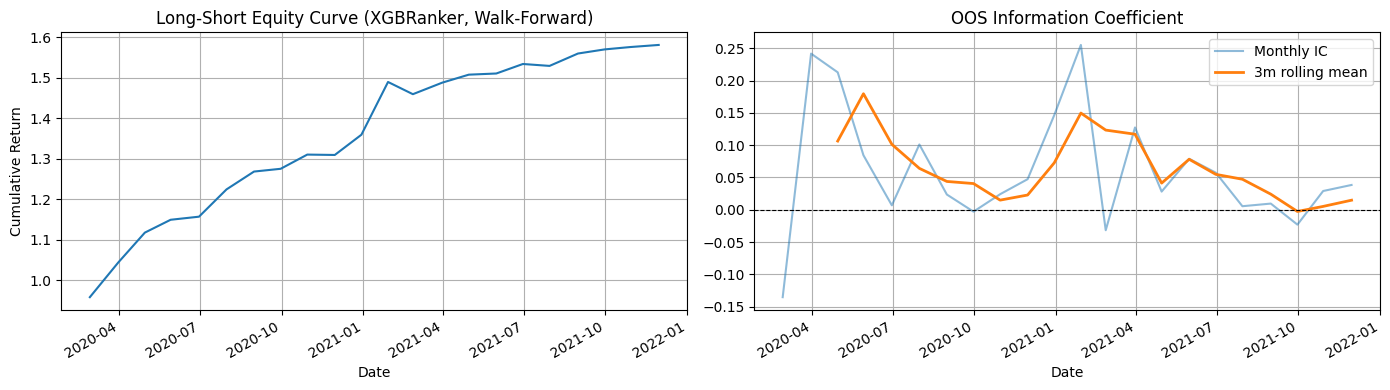

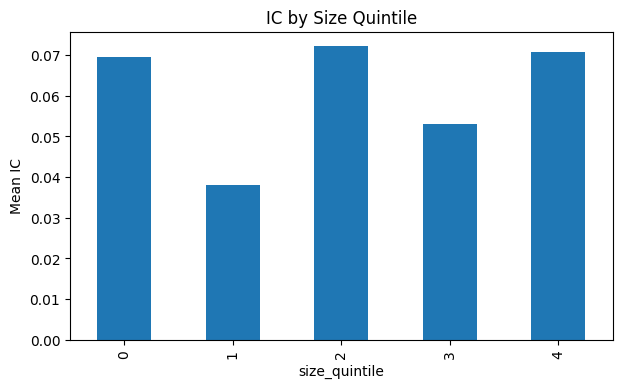

size_quintile
0    0.069584
1    0.038074
2    0.072175
3    0.053021
4    0.070741
dtype: float64


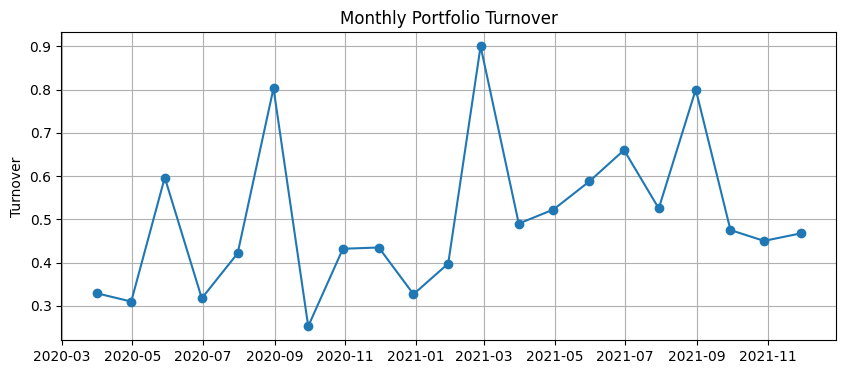

                             Date        Top     Bottom    Average
count                          21  21.000000  21.000000  21.000000
mean   2021-01-29 01:08:34.285714   0.448065   0.551691   0.499878
min           2020-03-31 00:00:00   0.206030   0.287879   0.252525
25%           2020-08-31 00:00:00   0.258883   0.447236   0.397500
50%           2021-01-29 00:00:00   0.395000   0.565000   0.467500
75%           2021-06-30 00:00:00   0.598985   0.606061   0.587500
max           2021-11-30 00:00:00   0.915000   0.885000   0.900000
std                           NaN   0.218892   0.151884   0.174005
Average turnover = 49.99%


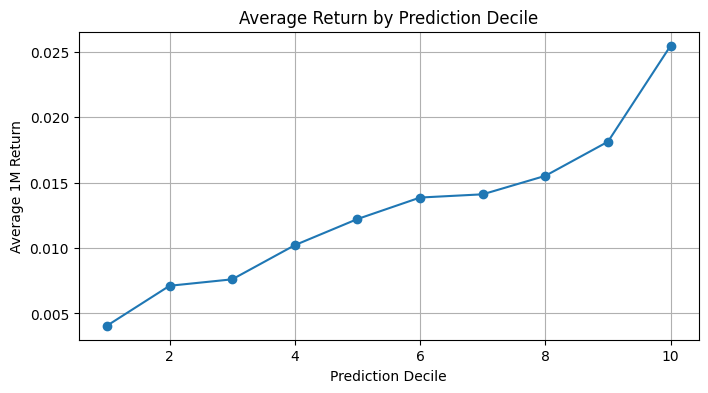

decile
0    0.004062
1    0.007117
2    0.007610
3    0.010223
4    0.012221
5    0.013864
6    0.014111
7    0.015525
8    0.018137
9    0.025474
Name: target_1m, dtype: float64
Top Positive Factors
vol_12m                      0.026647
ttm_operating_roa            0.013782
max_return_3m                0.011758
ttm_operating_margin         0.009885
vol_6m                       0.008989
earnings_yield               0.008946
vol_3m                       0.008335
ttm_sales_to_equity          0.006943
forecast_roe                 0.006776
forecast_roa                 0.006740
ttm_roa                      0.006690
ttm_profit_to_assets         0.006690
ttm_operating_roe            0.006609
Equity_yoy                   0.006282
forecast_operating_margin    0.004432
TotalAssets_yoy              0.003392
ttm_roe                      0.003201
ttm_asset_turnover           0.003122
mom_6m                       0.002590
ttm_ordinary_margin          0.002387
dtype: float64

Top Negative Factors
ma_

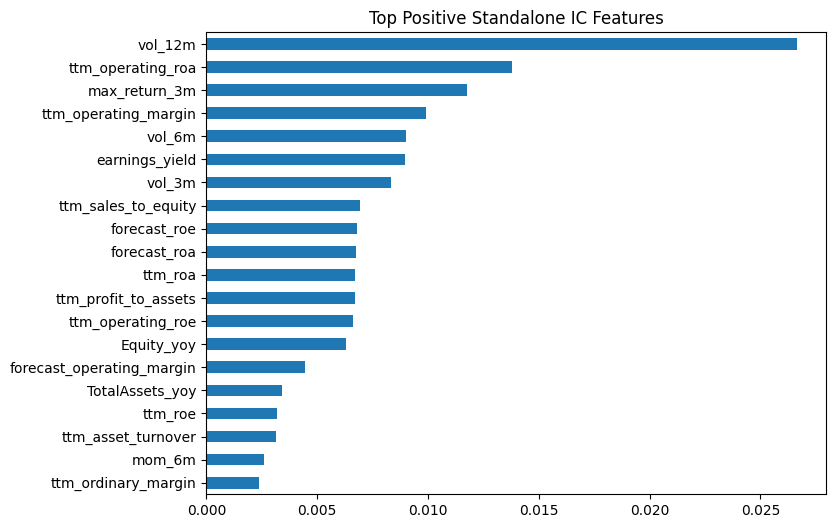

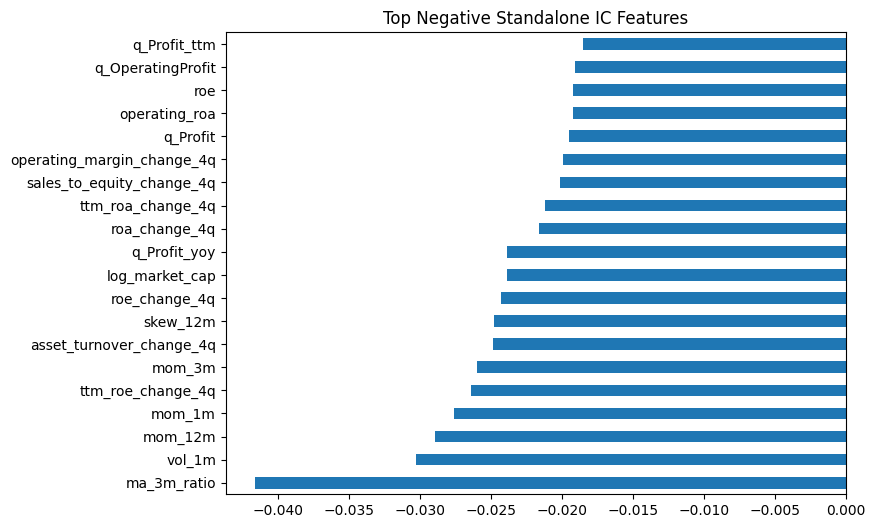

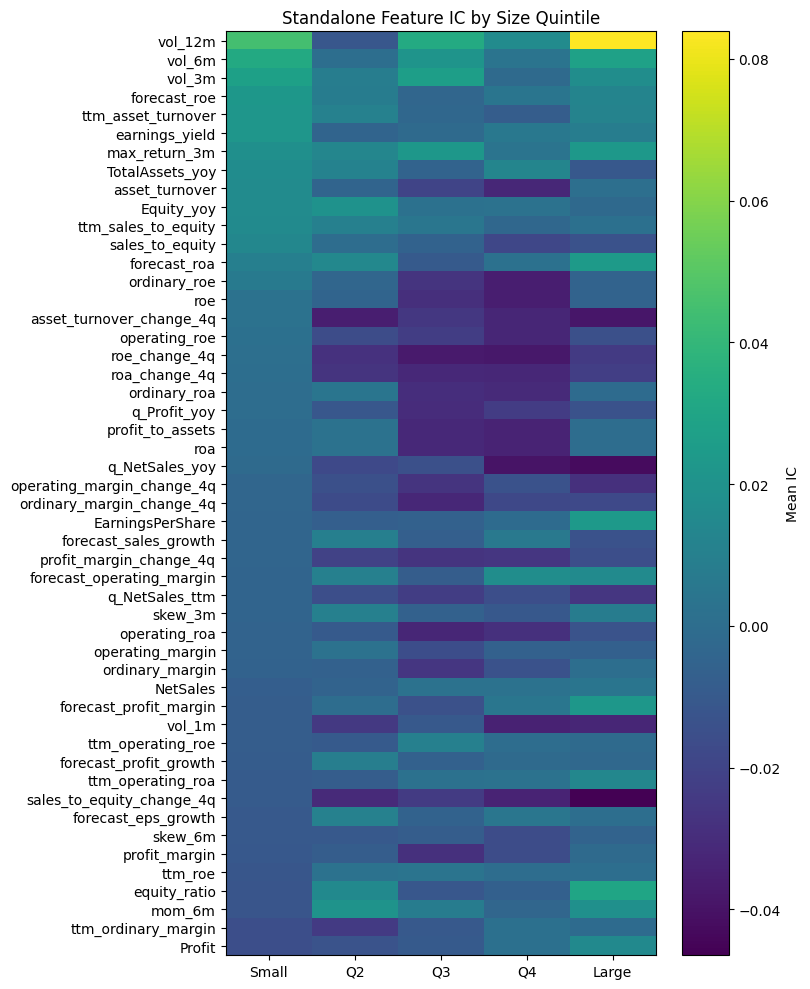

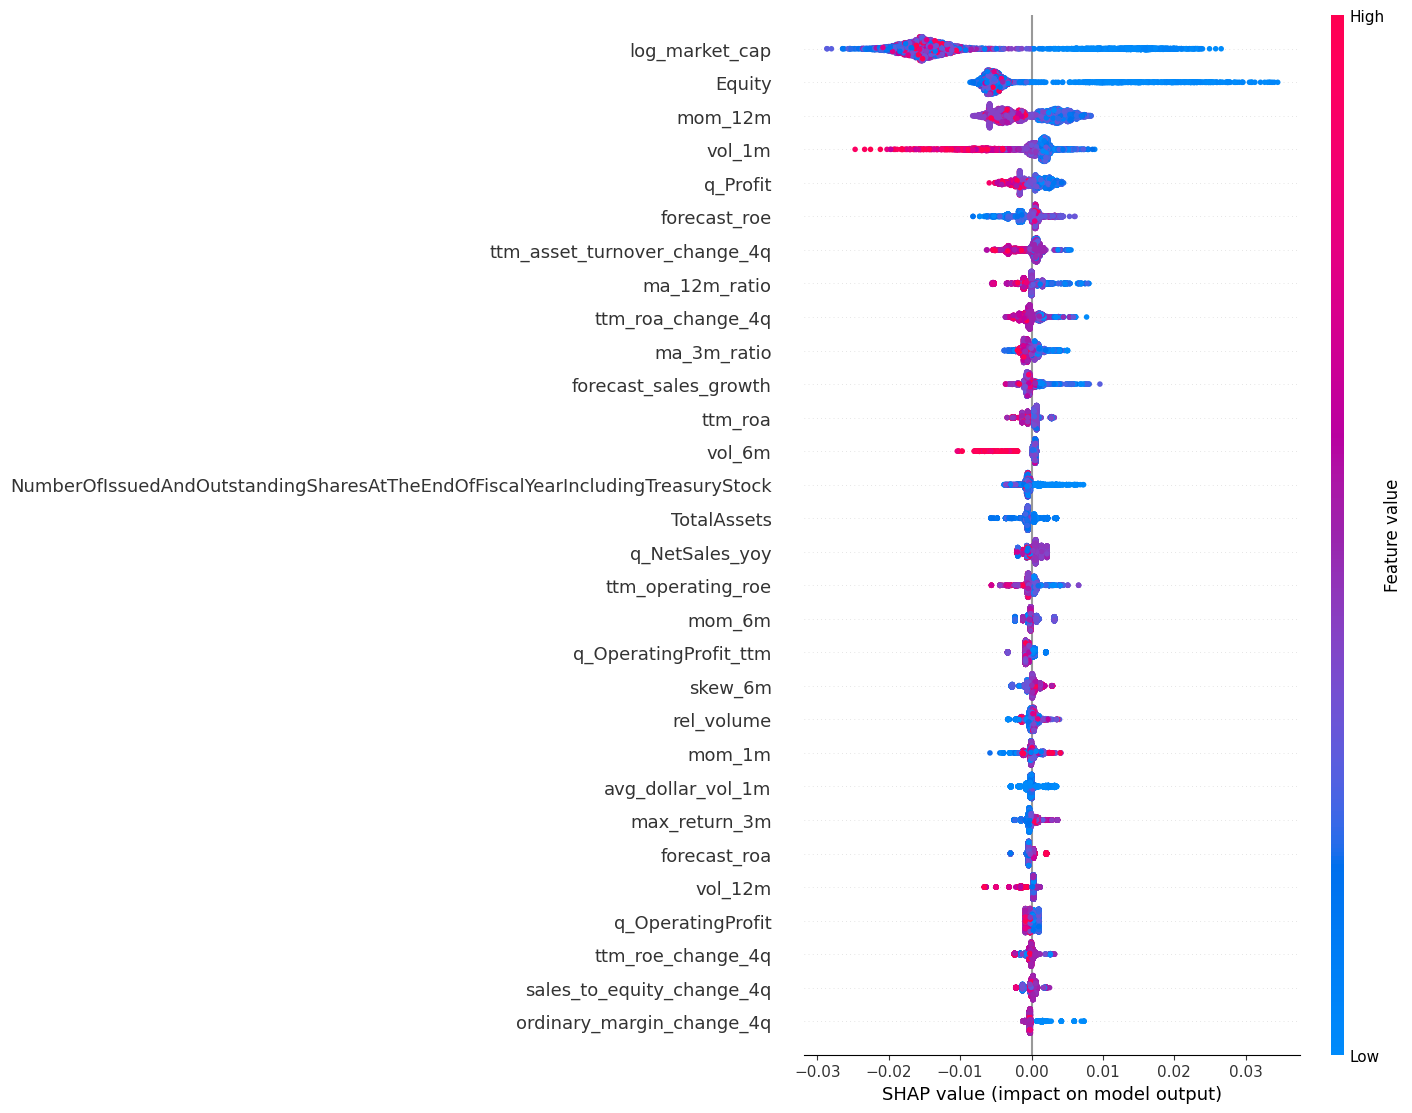

,feature,gain
76,log_market_cap,0.132487
4,Equity,0.041169
34,q_OrdinaryProfit_ttm,0.023904
42,ttm_ordinary_margin,0.017864
26,forecast_profit_growth,0.017572
33,q_OperatingProfit_ttm,0.017334
40,ttm_profit_margin,0.016892
66,vol_1m,0.016044
39,ttm_operating_roe,0.015285
1,NetSales,0.015134


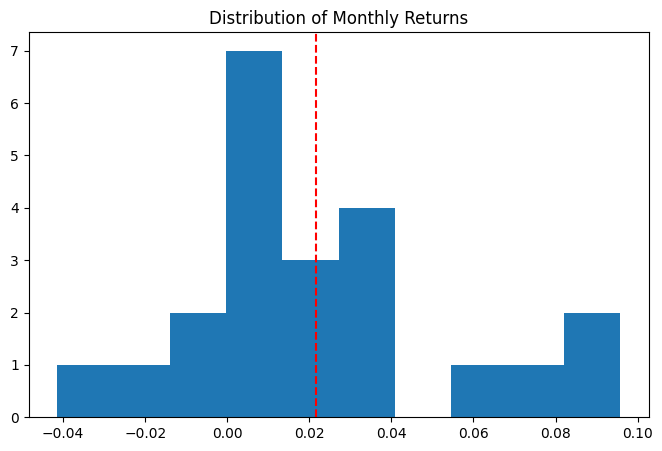

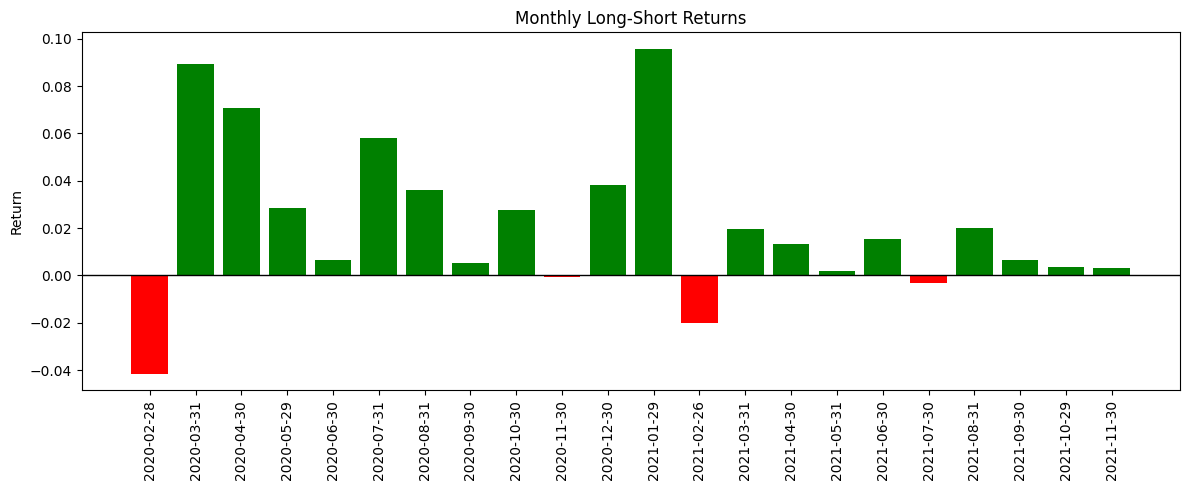


Final summary:
  Mean IC      : 0.0602
  ICIR         : 0.6496
  Annual ICIR  : 2.2503
  Avg L/S ret. : 2.1559%


In [69]:
# Stage 5 — walk-forward XGBRanker training & evaluation
results = run_stage5_train_and_evaluate(
    model_data, feature_cols, BEST_PARAMS_PATH, MODEL_DIR, verbose=True,
)

print("\nFinal summary:")
print(f"  Mean IC      : {results['monthly_ic'].mean():.4f}")
print(f"  ICIR         : {results['icir']:.4f}")
print(f"  Annual ICIR  : {results['annual_icir']:.4f}")
print(f"  Avg L/S ret. : {results['portfolio'].mean():.4%}")
